# PH22007: Scientific Computing in Python Coursework: Population Dynamics #

## Part 1: Rabbits and Foxes ##

The mathematical form is,
\begin{equation}
\begin{aligned}
\frac{dx}{dt} &= \alpha x - \beta xy, \\
\frac{dy}{dt} &= \delta xy - \gamma y,
\end{aligned}
\tag{1}
\end{equation}


where $x(t)$ is the rabbit (prey) population, $y(t)$ is the fox (predator) population,
$\alpha$ is the natural rabbit birth rate, $\beta$ is the predation rate (the rabbit death
rate from being eaten by foxes), $\gamma$ is the natural fox death rate,
and $\delta$ is the rate at which new foxes are created from rabbits being consumed.


In [46]:
# Adding intitial imports
import numpy as np 
import matplotlib . pyplot as plt 

In [47]:
# Define our ODE'S 
def F(t, S): # put all the variables that are used in both here as for ease
    M=np.array([[alpha,-beta*S[0]], 
                [delta*S[1],-gamma]])
# Using a Matrix for a more efficient way of computing the ODE 
    return np.dot(M,S) # This calculated the dot product and makes it clear it is matrices we are using 

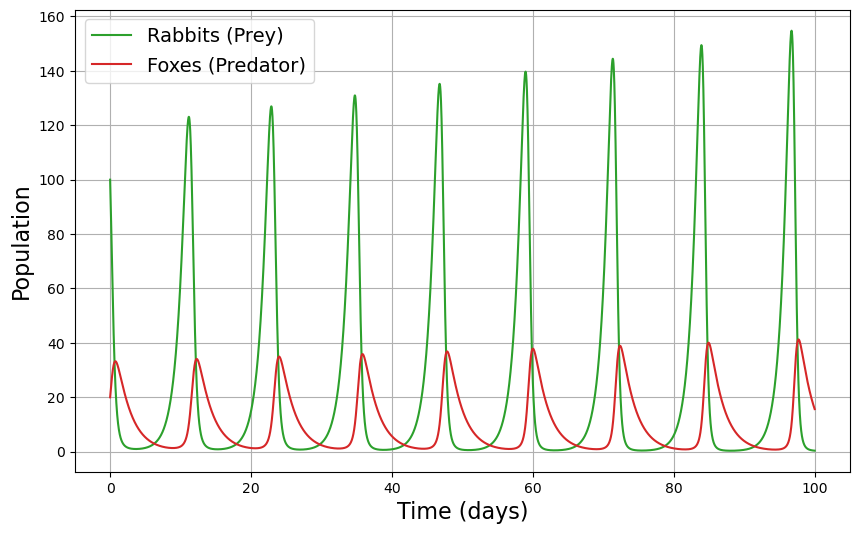

In [48]:

# Parameters
alpha = 1.0
beta  = 0.1
gamma = 0.5
delta = 0.02

# Initial conditions
x0 = 100.0
y0 = 20.0

# Time setup
t0 = 0.0
h = 0.01
Nstep = 10000
tf = t0 + Nstep * h

t = np.linspace(t0, tf, Nstep + 1)

# Arrays to store populations and filling these with zeros
x = np.zeros(Nstep + 1)
y = np.zeros(Nstep + 1)
S = np.zeros ( shape = ( Nstep+1, 2))


# Initial values need  to be set
S[0,0] = x0
S[0,1] = y0

# Euler's method
for i in range(Nstep):
 S[i+ 1 ,:] = S[i,:] + h * F(t[i],S[i,:])
# This takes the next row for all the clomuns and computes the y values and takes the gradient dunction from before, multiplies it by h and adds this to the previous one
# Plot Lotka–Volterra Predator–Prey Model (Euler’s Method)
plt.figure(figsize=(10,6))
plt.plot(t, S[:,0], label="Rabbits (Prey)", color="tab:green")
plt.plot(t, S[:,1], label="Foxes (Predator)", color="tab:red")
plt.xlabel("Time (days)", fontsize = 16)
plt.ylabel("Population", fontsize = 16)
plt.legend(fontsize = 14)
plt.grid(True)
plt.savefig('LotkaVolterra PredatorPrey Model Eulers Method.png')
plt.show()

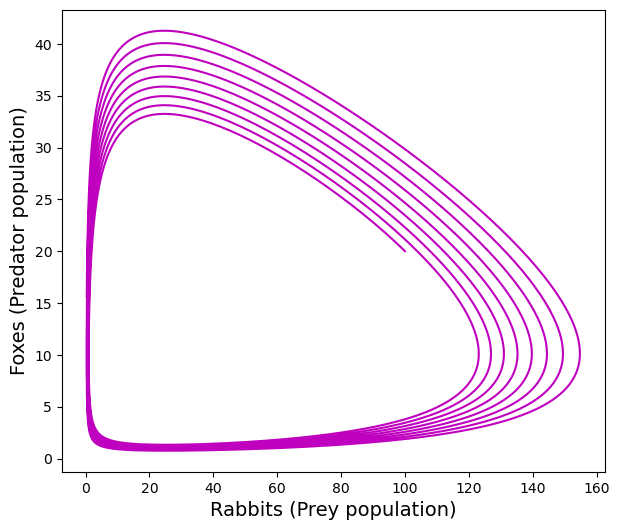

In [49]:
# Plotting the solutions parametrically in phase space
plt.figure(figsize=(7, 6))

#Phase-Space Trajectory of Predator–Prey System
plt.xlabel("Rabbits (Prey population)",fontsize = 14)
plt.ylabel("Foxes (Predator population)",fontsize = 14)


# Plotting it
plt.plot(S[:,0], S[:,1], 'm-') #Easier with the matrix as you select whole row with :
plt.savefig('RF phasespace.png')
plt.show()


## Question 2) Using the RK4 method ## 

### a) ###

In [52]:
from scipy . integrate import solve_ivp
# So we can solve with the RK4 using solve_ivp we have to add to the preamble

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-02 ...  9.999e+01  1.000e+02]
        y: [[ 1.000e+02  9.899e+01 ...  1.327e+01  1.338e+01]
            [ 2.000e+01  2.030e+01 ...  1.528e+00  1.524e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 60002
     njev: 0
      nlu: 0


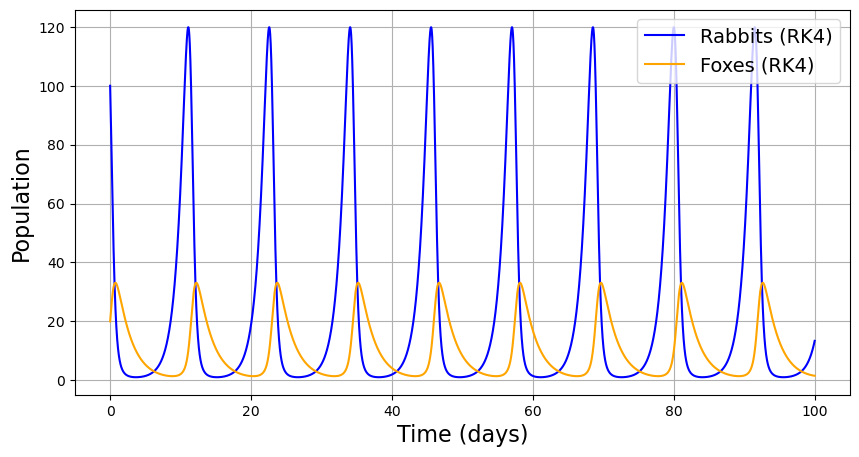

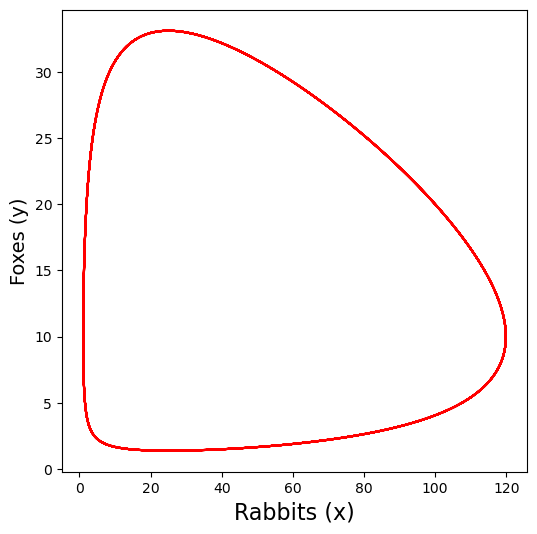

In [53]:
# Already have the function defined from before
# RK4 is more accurate as it is a weighted average fo different gradient points between the steps
# RK4 using matrix
ti=t0
t = np.linspace(ti, tf, Nstep+1)

sol = solve_ivp(F, [ti, tf], [x0, y0], t_eval=t,
                method='RK45', max_step = h) 
# Add max step so that the number of evaluations increases from 854 to 60002 so the line becomes more accurate
# Sol has a lot of freedom in what it defines to be its step size so we set it as our own,
# makes the line thinner and more precise
x_rk4 = sol.y[0]
y_rk4 = sol.y[1]
print (sol)
t_rk4 = sol.t

# Plot RK4 with populations and time
#Q2a: RK4 Method – Population vs Time
# More precise as is a 4th order approx and the other Euler one is a first order approx
plt.figure(figsize=(10, 5))
plt.plot(t, x_rk4, label="Rabbits (RK4)", color="blue")
plt.plot(t, y_rk4, label="Foxes (RK4)", color="orange")
plt.xlabel("Time (days)", fontsize = 16) # Increased fontsize for visibility
plt.ylabel("Population", fontsize = 16)
plt.savefig('RF RK4.png')
plt.grid(True)
plt.legend(loc = 'upper right', fontsize = 14) # Moving the legend for better aesthetics
plt.show()

# Plot RK4 with phase time graph just the simple one with nothing added to check shape
plt.figure(figsize=(6, 6))
plt.plot(x_rk4, y_rk4, color="red")
plt.xlabel("Rabbits (x)",fontsize = 16)
plt.ylabel("Foxes (y)",fontsize = 14)
plt.savefig('RF RK4 phasespace.png')
plt.show()

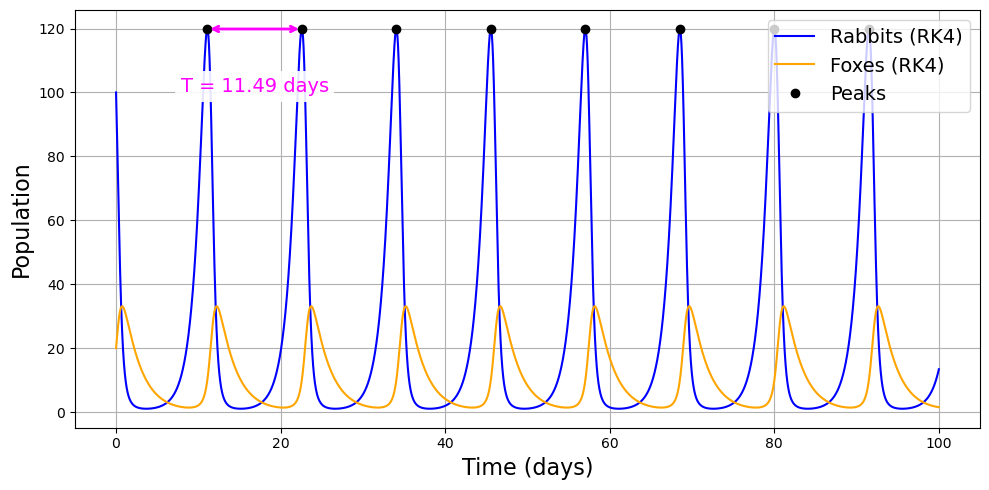

Estimated oscillation period: T = 11.49 days


In [54]:
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# Time setup
t0, tf = 0.0, 100.0
h = 0.01
Nstep = int((tf - t0) / h)

# Solve using RK4 (solve_ivp RK45)
t_eval = np.linspace(t0, tf, Nstep + 1)
sol = solve_ivp(F, [t0, tf], [x0, y0], t_eval=t_eval, method='RK45', max_step=h)

t_rk4 = sol.t
x_rk4 = sol.y[0]
y_rk4 = sol.y[1]

#Find rabbit peaks
peaks, _ = find_peaks(x_rk4, distance=200)
if len(peaks) >= 2:
    T = t_rk4[peaks[1]] - t_rk4[peaks[0]]  # time period
else:
    T = None

#Plotting
plt.figure(figsize=(10, 5))
plt.plot(t_rk4, x_rk4, label="Rabbits (RK4)", color="blue")
plt.plot(t_rk4, y_rk4, label="Foxes (RK4)", color="orange")

# Mark peaks
plt.plot(t_rk4[peaks], x_rk4[peaks], "ko", label="Peaks")

# Draw time period arrow and label
if T is not None:
    t1, t2 = t_rk4[peaks[0]], t_rk4[peaks[1]]
    y_mid = (x_rk4[peaks[0]] + x_rk4[peaks[1]]) / 2
    plt.annotate(
        "", xy=(t1, y_mid), xytext=(t2, y_mid),
        arrowprops=dict(arrowstyle="<->", color="magenta", lw=2.0)
    )
    plt.text(
        (t1 + t2) / 2, y_mid - 15,   # moving time label to the right position
        f"T = {T:.2f} days",
        ha="center", va="top", fontsize=14, color="magenta",
        bbox=dict(facecolor="white", alpha=0.9, edgecolor='none')
    )


plt.xlabel("Time (days)", fontsize=16)
plt.ylabel("Population", fontsize=16)
plt.grid(True)
plt.legend(loc="upper right", fontsize=14)
plt.tight_layout()
plt.savefig('RF_RK4_with_period.png', dpi=300)
plt.show()

if T:
    print(f"Estimated oscillation period: T = {T:.2f} days")


## Q2b) Fixed stationary points ##

## Q2c) ##

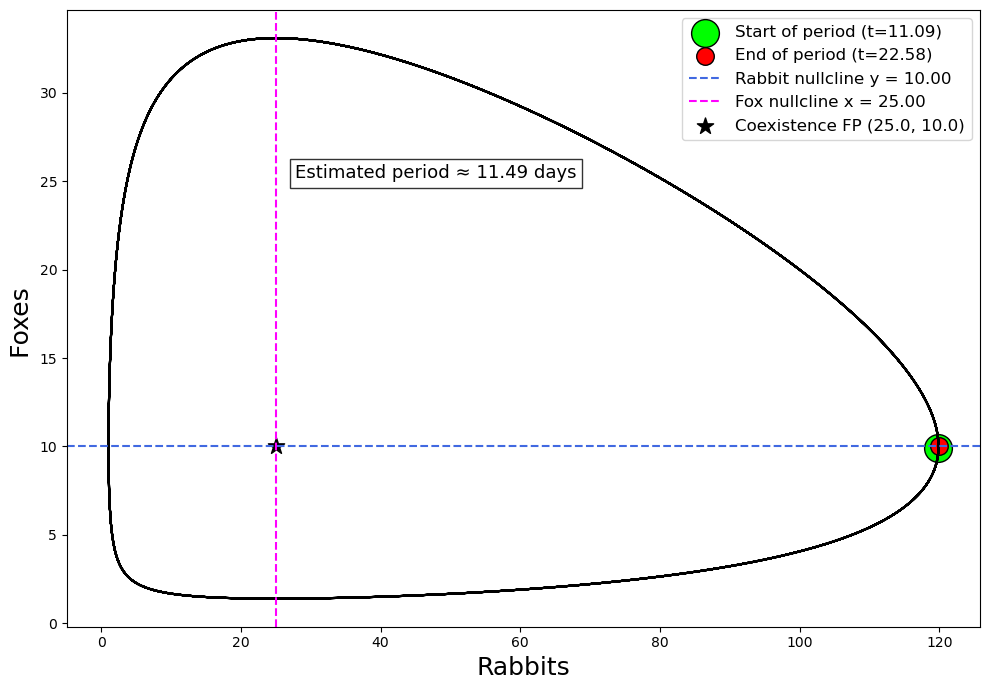

In [57]:
# Solve system
t_eval = np.linspace(t0, tf, Nstep+1)
sol = solve_ivp(F, [t0, tf], [x0, y0], t_eval=t_eval, max_step=h)
x, y = sol.y
t = sol.t

# Finding period
peaks, _ = find_peaks(x, distance=200) 


# start and end of one period being labelled and selecting 2nd and third as first peak differs
i_start = peaks[0]
i_end   = peaks[1]

t_start = t[i_start]
t_end   = t[i_end]
period  = t_end - t_start

x_start, y_start = x[i_start], y[i_start]
x_end,   y_end   = x[i_end],   y[i_end]

# Nullclines
rabbit_nullcline_y = alpha / beta
fox_nullcline_x = gamma / delta

#Plotting phase space
plt.figure(figsize=(10, 7))
plt.plot(x, y, color="k")

# Start & End of one period being shown
plt.scatter(x_start, y_start, s=400, color="lime", edgecolor="black", # Make the size of the marker bigger so can see underneath
            label=f"Start of period (t={t_start:.2f})")

plt.scatter(x_end, y_end, s=160, color="red", edgecolor="black",
            label=f"End of period (t={t_end:.2f})")

# Nullclines
plt.axhline(rabbit_nullcline_y, color="royalblue", linestyle="--",
            label=f"Rabbit nullcline y = {rabbit_nullcline_y:.2f}")
plt.axvline(fox_nullcline_x, color="magenta", linestyle="--",
            label=f"Fox nullcline x = {fox_nullcline_x:.2f}")

# Coexistence fixed point
plt.scatter(*FP2, s=150, color="black", marker="*", 
            label=f"Coexistence FP {FP2}")

# Period annotation
plt.text(0.25, 0.75,#Moving the label around the figure
         f"Estimated period ≈ {period:.2f} days",
         transform=plt.gca().transAxes,
         fontsize=13, # Increasing fontsize
         verticalalignment='top', #Positioning
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))

# Final plotting of phase space diagram
plt.xlabel("Rabbits", fontsize=18)
plt.ylabel("Foxes ", fontsize=18)
plt.legend(fontsize = 12)
plt.tight_layout()
plt.savefig('RF_RK4_phase with one_period.png')
plt.show()


# Part 2 - Zombie Outbreak #

## Q1) ##

TZombie outbreak has this system of ODEs,
\begin{equation}
\begin{aligned}
\frac{dH}{dt} &= \alpha H - \beta H - \gamma HZ, \\
\frac{dZ}{dt} &= \gamma HZ - \delta HZ + \epsilon D, \\
\frac{dD}{dt} &= \beta H + \delta HZ - \epsilon D,
\end{aligned}
\tag{2}
\end{equation}



where $H(t)$ is the population of Humans, $Z(t)$ is the population of Zombies,
$D(t)$ is the ''population'' of Dead, $\alpha$ is the human natural birth rate,
$\beta$ is the human natural death rate, $\gamma$ is the so-called
''zombification'' rate (the rate at which humans are converted into zombies),
$\delta$ is the zombie destruction rate (the rate at which zombies are destroyed
by humans and become dead), and $\epsilon$ is the resurrection rate (the rate at
which the dead are resurrected as zombies).

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-02 ...  4.990e+00  5.000e+00]
        y: [[ 1.000e+03  9.995e+02 ...  6.691e-16  6.087e-16]
            [ 5.000e+00  5.493e+00 ...  9.944e+02  9.944e+02]
            [ 0.000e+00  6.241e-03 ...  1.058e+01  1.058e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 3008
     njev: 0
      nlu: 0


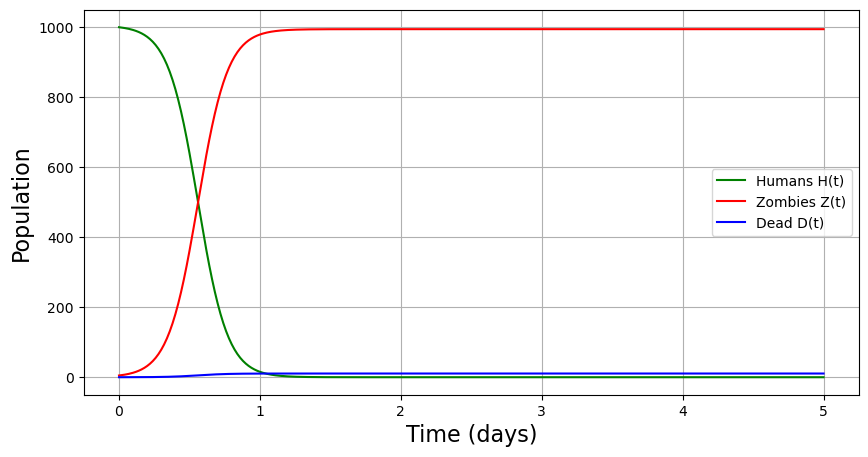

In [62]:
#Defining ODEs again 
def F(t, S):
    # S = [H, Z, D]
    H, Z, D = S

# Matrix form M(S)
# This matrix is constructed so that M(S) dot S gives the RHS of the zombie ODEs.
    M = np.array([
        [(alpha - beta) - gamma * Z,       0.0,                 0.0],
        [0.0,                        (gamma - delta) * H,       eps],
        [beta,                            delta * H,           -eps]
    ], dtype=float)

    return np.dot(M, S)   # Returns [dH/dt, dZ/dt, dD/dt] 

#  Parameters given 
alpha = 0.0  # the human natural birth rate
beta  = 1.0e-4 # the natural human death rate
gamma = 9.5e-3 # rate at which humans are converted into zombies ( Zombification rate)
delta = 1.0e-4 # rate at which zombies are destroyed by humans and become dead (Zombie destruction rate)
eps   = 1.0e-4 # rate at which the dead are resurrected as zombies (resurrection rate)

# Initial conditions
H0 = 1000.0 # Initial humans
Z0 = 5.0 # Initial zombies
D0 = 0.0 # Initial dead

# Time elements
t0 = 0.0 # Initial time is zero
tf = 5.0 # The final time in days
h  = 0.01  # step size in days
Nstep = int((tf - t0) / h)
t = np.linspace(t0, tf, Nstep + 1) # from the initial to the final time with the number of steps
# This creates a uniform array of times that we can put in for t_eval so that SciPy returns values at the specific time points we want


# Solve using solve_ivp with RK45 
sol = solve_ivp(F, [t0, tf], [H0, Z0, D0],
                t_eval = t, method="RK45", max_step=h)
# Max steps set as h means there are smaller solver steps so theres higher accuracy and smoother lines

# Extract solutions
H_rk4 = sol.y[0] # for humans
Z_rk4 = sol.y[1] # For zombies
D_rk4 = sol.y[2] # For dead
t_rk4 = sol.t # This is the time grid we use

print(sol)   # For reference


# Plot of populations of both against time
plt.figure(figsize=(10,5))
plt.plot(t_rk4, H_rk4, label="Humans H(t)", color="green")
plt.plot(t_rk4, Z_rk4, label="Zombies Z(t)", color="red")
plt.plot(t_rk4, D_rk4, label="Dead D(t)", color="blue")
plt.xlabel("Time (days)", fontsize = 16) # Making fontsize bigger and more visible
plt.ylabel("Population", fontsize = 16)
plt.grid(True)
plt.legend()
plt.show()
# Shows Humans decreasing, Zombies increasing, Dead increasing


## Q2) ##

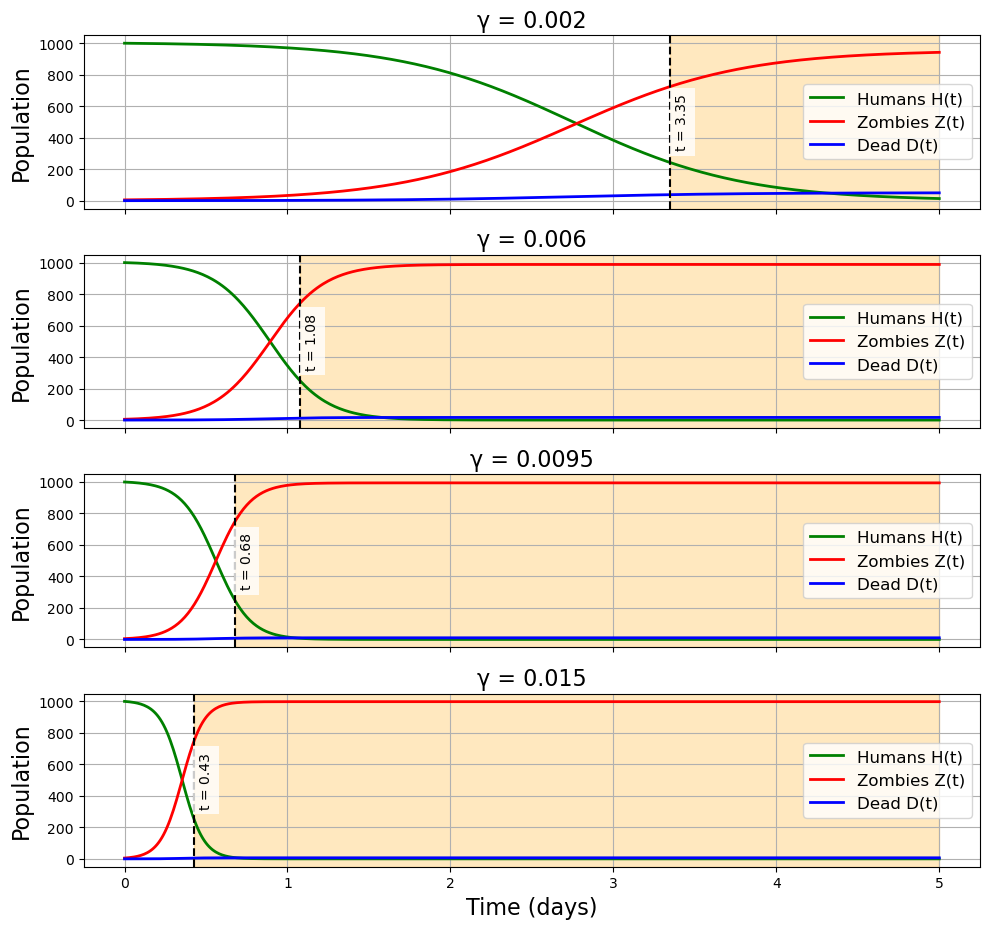

In [64]:
# Zombie model (matrix form) # Now taking out the variables in the function as we are changing gamma
def F(t, S, alpha, beta, gamma, delta, eps):
    H, Z, D = S
    M = np.array([
        [(alpha - beta) - gamma * Z, 0.0, 0.0],
        [0.0, (gamma - delta)*H, eps],
        [beta, delta*H, -eps]
    ])
    return M @ S


#RK4 solving
def solve_rk4_matrix(t0, tf, h, S0, alpha, beta, gamma, delta, eps):
    t_eval = np.linspace(t0, tf, int((tf - t0)/h) + 1)
    sol = solve_ivp(
        lambda t, S: F(t, S, alpha, beta, gamma, delta, eps),
        [t0, tf], S0,
        t_eval=t_eval,
        method='RK45',
        max_step=h
    )
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

# Outbreak time detection (Z = 3H)
def outbreak_time(H, Z, t, k=3.0):
    diff = Z - k*H
    idx = np.where(diff[:-1] * diff[1:] <= 0)[0]
    if len(idx) == 0:
        return None
    i = idx[0]
    w = diff[i] / (diff[i] - diff[i+1])
    return t[i] + w*(t[i+1] - t[i])

# 4 gamma values including the default value
gamma_list = [0.002, 0.006, 0.0095, 0.015]

# Initial populations
S0 = np.array([1000., 5., 0.])  
t0, tf, h = 0.0, 5.0, 0.01


#Solve for gamma
solutions = {}
for g in gamma_list:
    t, H, Z, D = solve_rk4_matrix(t0, tf, h, S0, alpha, beta, g, delta, eps)
    T_out = outbreak_time(H, Z, t, k=3.0)
    solutions[g] = (t, H, Z, D, T_out)



# Stacked plots with H(t), Z(t), D(t) and shading for outbreak

fig, axes = plt.subplots(len(gamma_list), 1, figsize=(10, 10), sharex=True)

for ax, g in zip(axes, gamma_list):
    t, H, Z, D, T_out = solutions[g]

    # Plot populations with REVISED colours
    ax.plot(t, H, label="Humans H(t)", color='green', lw=2)
    ax.plot(t, Z, label="Zombies Z(t)", color='red', lw=2)
    ax.plot(t, D, label="Dead D(t)", color='blue', lw=2)
    
    y_min = min(np.min(H), np.min(Z), np.min(D))
    y_max = max(np.max(H), np.max(Z), np.max(D))
    y_mid = 0.5 * (y_min + y_max)

    # Outbreak line & shading
    if T_out is not None:
        ax.axvline(T_out, color='black', linestyle='--', linewidth=1.5)
        ax.axvspan(T_out, tf, color='orange', alpha=0.25)

        ax.text(
        T_out + 0.03,      # slightly to the right so it's easy to read
        y_mid,             # centered vertically
        f"t = {T_out:.2f}",
        rotation=90,
        fontsize=10,
        color="black",
        ha='left',
        va='center',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)
    ax.set_ylabel("Population", fontsize = 16)
    ax.set_title(f"γ = {g}",fontsize = 16)
    ax.grid(True)
    ax.legend(loc="center right", fontsize = 12)

axes[-1].set_xlabel("Time (days)", fontsize = 16)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('Different gammas and outbreak zone.png')
plt.show()


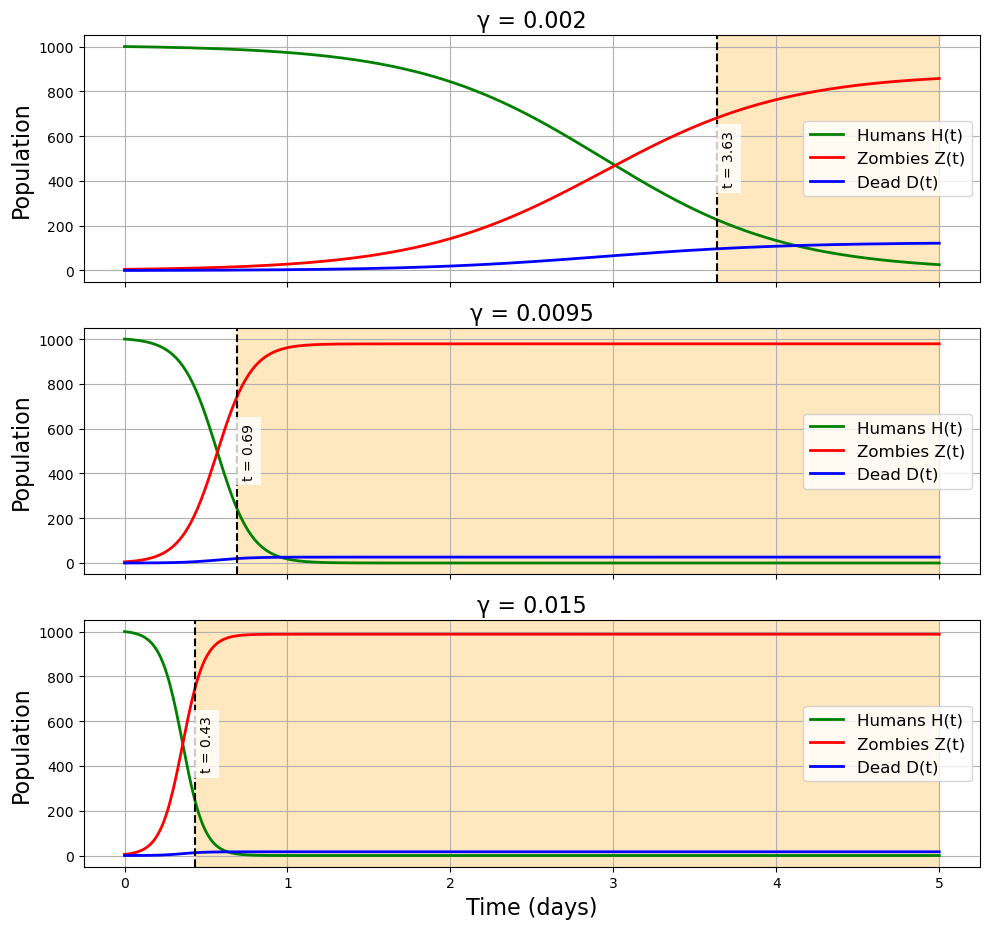

In [151]:
# With only 3 gammas
# Zombie model (matrix form)
def F(t, S, alpha, beta, gamma, delta, eps):
    H, Z, D = S
    M = np.array([
        [(alpha - beta) - gamma * Z, 0.0, 0.0],
        [0.0, (gamma - delta) * H, eps],
        [beta, delta * H, -eps]
    ])
    return M @ S


# RK4 solving
def solve_rk4_matrix(t0, tf, h, S0, alpha, beta, gamma, delta, eps):
    t_eval = np.linspace(t0, tf, int((tf - t0)/h) + 1)
    sol = solve_ivp(
        lambda t, S: F(t, S, alpha, beta, gamma, delta, eps),
        [t0, tf], S0,
        t_eval=t_eval,
        method='RK45',
        max_step=h
    )
    return sol.t, sol.y[0], sol.y[1], sol.y[2]


# Outbreak time detection (Z = 3H)
def outbreak_time(H, Z, t, k=3.0):
    diff = Z - k * H
    idx = np.where(diff[:-1] * diff[1:] <= 0)[0]
    if len(idx) == 0:
        return None
    i = idx[0]
    w = diff[i] / (diff[i] - diff[i+1])
    return t[i] + w * (t[i+1] - t[i])


# Gamma values (removed γ = 0.006)
gamma_list = [0.002, 0.0095, 0.015]

# Initial populations
S0 = np.array([1000., 5., 0.])
t0, tf, h = 0.0, 5.0, 0.01

# Solve for each gamma
solutions = {}
for g in gamma_list:
    t, H, Z, D = solve_rk4_matrix(t0, tf, h, S0, alpha, beta, g, delta, eps)
    T_out = outbreak_time(H, Z, t, k=3.0)
    solutions[g] = (t, H, Z, D, T_out)


# Stacked plots with H(t), Z(t), D(t) and shading for outbreak
fig, axes = plt.subplots(len(gamma_list), 1, figsize=(10, 10), sharex=True)

for ax, g in zip(axes, gamma_list):
    t, H, Z, D, T_out = solutions[g]

    ax.plot(t, H, label="Humans H(t)", color='green', lw=2)
    ax.plot(t, Z, label="Zombies Z(t)", color='red', lw=2)
    ax.plot(t, D, label="Dead D(t)", color='blue', lw=2)

    y_min = min(np.min(H), np.min(Z), np.min(D))
    y_max = max(np.max(H), np.max(Z), np.max(D))
    y_mid = 0.5 * (y_min + y_max)

    # Outbreak line & shading
    if T_out is not None:
        ax.axvline(T_out, color='black', linestyle='--', linewidth=1.5)
        ax.axvspan(T_out, tf, color='orange', alpha=0.25)

        ax.text(
            T_out + 0.03,
            y_mid,
            f"t = {T_out:.2f}",
            rotation=90,
            fontsize=10,
            color="black",
            ha='left',
            va='center',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )

    ax.set_ylabel("Population", fontsize=16)
    ax.set_title(f"γ = {g}", fontsize=16)
    ax.grid(True)
    ax.legend(loc="center right", fontsize=12)

axes[-1].set_xlabel("Time (days)", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Different gammas and outbreak zone.png")
plt.show()


## Q2) ##

Equation:  T = 0.006515 / γ
Coefficient: a = 0.006515


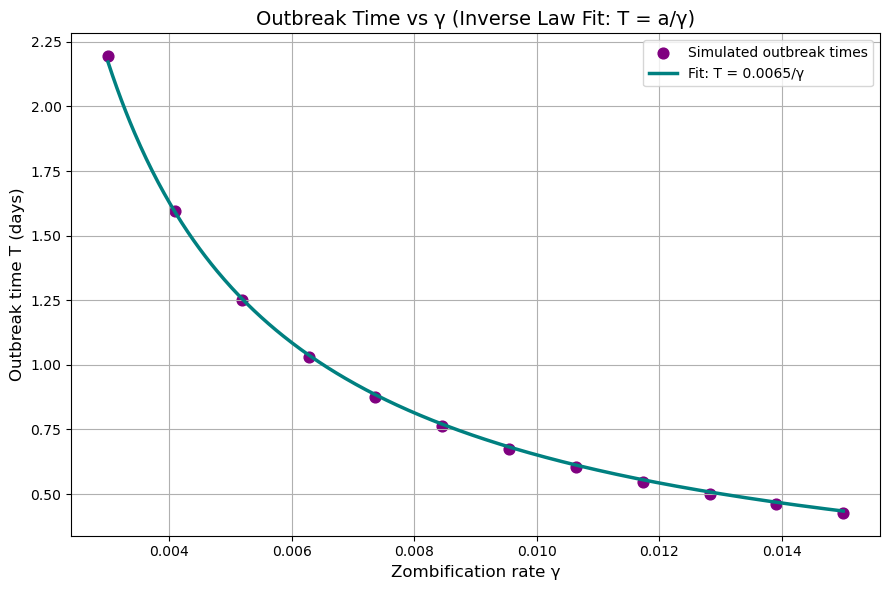

In [66]:
# Solve using RK4 via solve_ivp
def solve_zombies(t0, tf, h, S0, alpha, beta, gamma, delta, eps):
    t_eval = np.linspace(t0, tf, int((tf-t0)/h) + 1)
    sol = solve_ivp(lambda t, S: F(t, S, alpha, beta, gamma, delta, eps),
                    [t0, tf], S0, t_eval=t_eval,
                    method="RK45", max_step=h)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]


# Outbreak condition of Z >= 3H
def outbreak_time(H, Z, t):
    diff = Z - 3*H
    idx = np.where(diff[:-1] * diff[1:] <= 0)[0]
    if len(idx) == 0:
        return np.nan  # no outbreak
    i = idx[0]
    # linear interpolation for accuracy
    w = diff[i] / (diff[i] - diff[i+1])
    return t[i] + w*(t[i+1] - t[i])

t0, tf, h = 0.0, 5.0, 0.01

#Range of gamma values
gamma_vals = np.linspace(0.003, 0.015, 12)

T_vals = []
for g in gamma_vals:
    t, H, Z, D = solve_zombies(t0, tf, h, S0, alpha, beta, g, delta, eps)
    T_vals.append(outbreak_time(H, Z, t))

T_vals = np.array(T_vals)


mask = np.isfinite(T_vals)
g = gamma_vals[mask]
T = T_vals[mask]

# Solve least-squares for a
# We minimise |T - a/g|^2  ⇒  a = (Σ(T/g)) / (Σ(1/g²))
a = np.sum(T / g) / np.sum(1 / g**2)

print(f"Equation:  T = {a:.6f} / γ")
print(f"Coefficient: a = {a:.6f}")


# Plot
plt.figure(figsize=(9,6))

# Simulation data
plt.scatter(g, T, color="purple", s=60, label="Simulated outbreak times")

# Fitted curve
xx = np.linspace(g.min(), g.max(), 500)
plt.plot(xx, a/xx, color="teal", linewidth=2.5, label=f"Fit: T = {a:.4f}/γ")

plt.xlabel("Zombification rate γ", fontsize=12)
plt.ylabel("Outbreak time T (days)", fontsize=12)
plt.title("Outbreak Time vs γ (Inverse Law Fit: T = a/γ)", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


a ≈ 0.006515, so T ≈ 0.006515 / γ


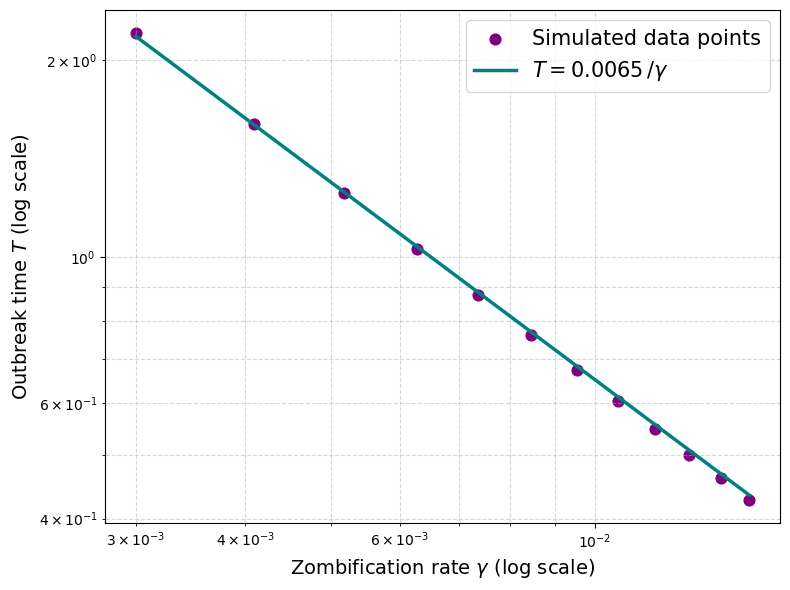

In [103]:

def F(t, S, alpha, beta, gamma, delta, eps):
    H, Z, D = S
    dH = -beta*H - gamma*H*Z
    dZ =  gamma*H*Z - delta*H*Z + eps*D
    dD =  beta*H + delta*H*Z - eps*D
    return np.array([dH, dZ, dD])
    
def solve_zombies(t0, tf, h, S0, alpha, beta, gamma, delta, eps):
    t_eval = np.linspace(t0, tf, int((tf - t0)/h) + 1)
    sol = solve_ivp(
        lambda t, S: F(t, S, alpha, beta, gamma, delta, eps),
        [t0, tf],
        S0,
        t_eval=t_eval,
        method="RK45",
        max_step=h
    )
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

# Outbreak condition: Z = 3H
def outbreak_time(H, Z, t):
    diff = Z - 3*H
    idx = np.where(diff[:-1] * diff[1:] <= 0)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    w = diff[i] / (diff[i] - diff[i+1])
    return t[i] + w * (t[i+1] - t[i])


# Compute outbreak times
T_vals = []
for g in gamma_vals:
    t, H, Z, D = solve_zombies(t0, tf, h, S0, alpha, beta, g, delta, eps)
    T_vals.append(outbreak_time(H, Z, t))

T_vals = np.array(T_vals)
mask = np.isfinite(T_vals)
g = gamma_vals[mask]
T = T_vals[mask]

# Fit T = a / gamma  (least squares)
a = np.sum(T / g) / np.sum(1 / g**2)
print(f"a ≈ {a:.6f}, so T ≈ {a:.6f} / γ")

# log graph plotting
plt.figure(figsize=(8, 6))
plt.scatter(g, T, color="purple", s=60, label="Simulated data points")
xx = np.linspace(g.min(), g.max(), 400)
plt.plot(xx, a/xx, color="teal", linewidth=2.5,
         label=f"$T = {a:.4f}\\,/\\gamma$")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Zombification rate $\\gamma$ (log scale)", fontsize=14)
plt.ylabel("Outbreak time $T$ (log scale)", fontsize=14)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize = 15)
plt.tight_layout()
plt.savefig("log outbreak time graph.png", dpi=300)
plt.show()


## Part 3 ##

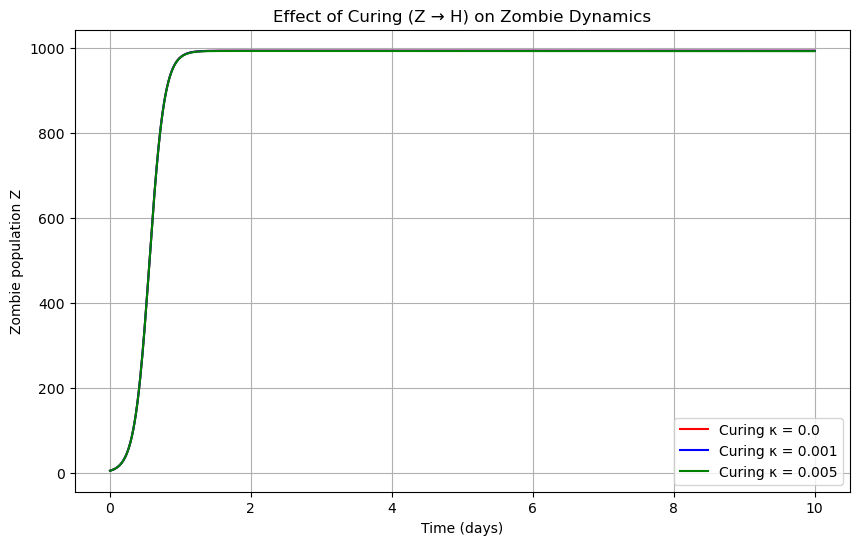

In [115]:
def F_curing(t, S, alpha, beta, gamma, delta, eps, kappa):
    """
    Extended zombie model including curing (Z → H at rate kappa).
    """
    H, Z, D = S
    
    # Matrix form dS/dt = M(S) * S
    M = np.array([
        [(alpha - beta) - gamma*Z,   kappa,             0.0],
        [0.0,                        (gamma-delta)*H - kappa, eps],
        [beta,                       delta*H,           -eps]
    ])
    
    return M @ S

def solve_rk4_extended(t0, tf, h, S0, alpha, beta, gamma, delta, eps, kappa):
    t_eval = np.linspace(t0, tf, int((tf-t0)/h)+1)
    sol = solve_ivp(
        lambda t, S: F_curing(t, S, alpha, beta, gamma, delta, eps, kappa),
        [t0, tf], S0, t_eval=t_eval,
        method="RK45", max_step=h
    )
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

# ============================================================
# Example: Show how curing affects the outbreak
# ============================================================

alpha = 0.0
beta  = 1e-4
gamma = 9.5e-3
delta = 1e-4
eps   = 1e-4

H0, Z0, D0 = 1000., 5., 0.
S0 = np.array([H0, Z0, D0])

t0, tf, h = 0.0, 10.0, 0.01

# Try 3 curing values
kappas = [0.0, 0.001, 0.005]
colors = ["red", "blue", "green"]

plt.figure(figsize=(10,6))

for kappa, col in zip(kappas, colors):
    t, H, Z, D = solve_rk4_extended(t0, tf, h, S0, alpha, beta, gamma, delta, eps, kappa)
    plt.plot(t, Z, color=col, label=f"Curing κ = {kappa}")

plt.xlabel("Time (days)")
plt.ylabel("Zombie population Z")
plt.title("Effect of Curing (Z → H) on Zombie Dynamics")
plt.grid(True)
plt.legend()
plt.show()


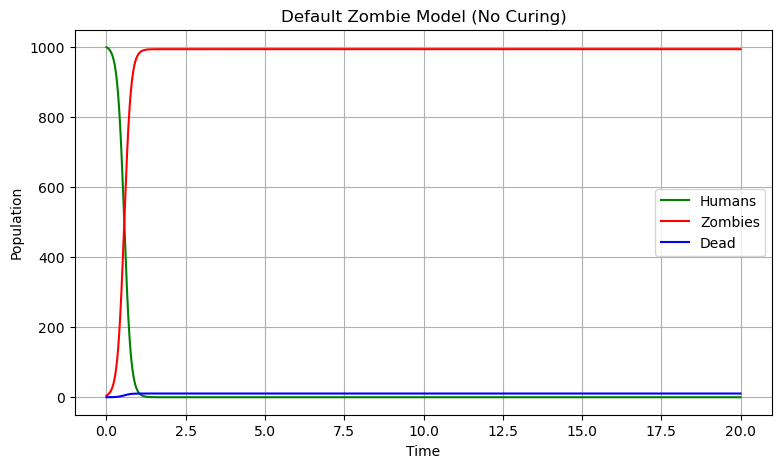

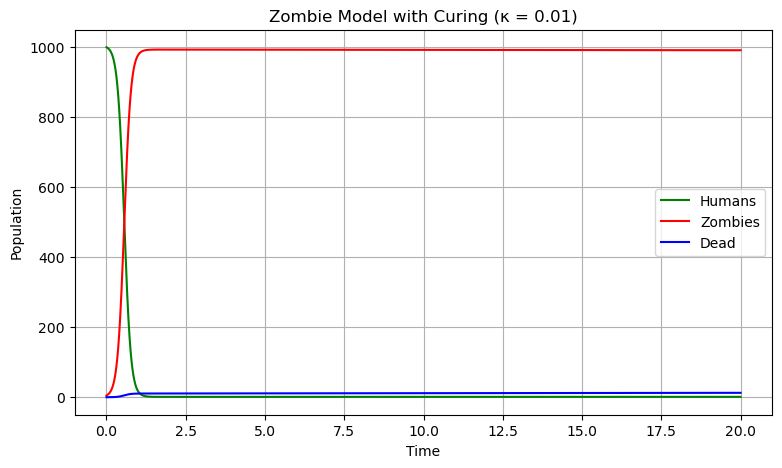

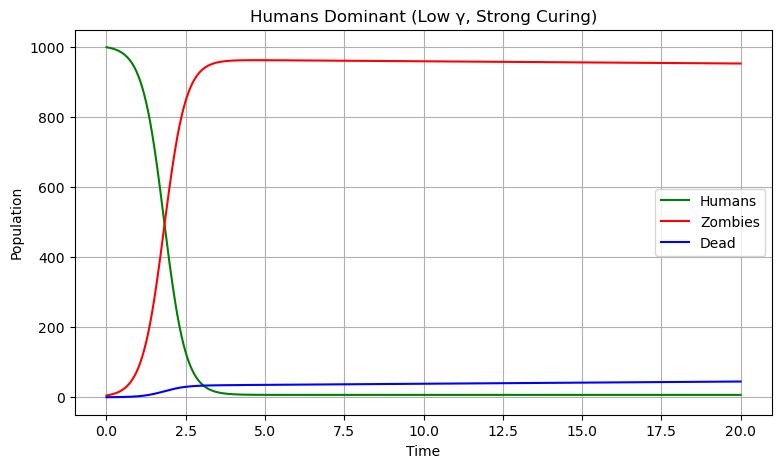

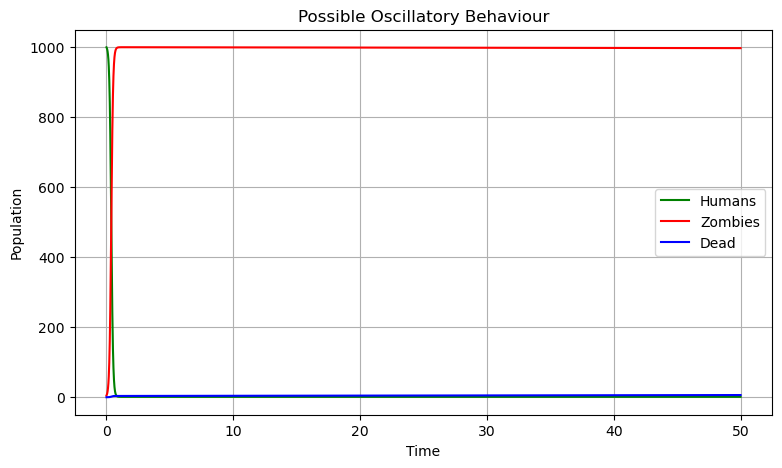

In [121]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---------------------------------------------------------
# Zombie model with optional curing term
# ---------------------------------------------------------
def zombie_model(t, S, alpha, beta, gamma, delta, eps, kappa=0.0):
    H, Z, D = S

    dH = -beta*H - gamma*H*Z + kappa*Z       # curing adds humans
    dZ = gamma*H*Z - delta*H*Z + eps*D - kappa*Z   # curing removes zombies
    dD = beta*H + delta*H*Z - eps*D

    return np.array([dH, dZ, dD])


# ---------------------------------------------------------
# Solve system
# ---------------------------------------------------------
def solve_system(params, t0=0, tf=20, h=0.01):
    alpha, beta, gamma, delta, eps, kappa = params
    S0 = [1000, 5, 0]
    t_eval = np.linspace(t0, tf, int((tf-t0)/h)+1)

    sol = solve_ivp(lambda t, S: zombie_model(t, S, alpha, beta, gamma, delta, eps, kappa),
                    [t0, tf], S0, t_eval=t_eval)

    return sol.t, sol.y[0], sol.y[1], sol.y[2]


# ---------------------------------------------------------
# Plotting helper
# ---------------------------------------------------------
def plot_system(t, H, Z, D, title=""):
    plt.figure(figsize=(9,5))
    plt.plot(t, H, label="Humans", color="green")
    plt.plot(t, Z, label="Zombies", color="red")
    plt.plot(t, D, label="Dead", color="blue")
    plt.xlabel("Time")
    plt.ylabel("Population")
    plt.legend()
    plt.grid(True)
    plt.title(title)
    plt.show()


# ---------------------------------------------------------
# 1) DEFAULT MODEL (no curing)
# ---------------------------------------------------------
params_no_cure = (0.0, 1e-4, 9.5e-3, 1e-4, 1e-4, 0.0)
t, H, Z, D = solve_system(params_no_cure)
plot_system(t, H, Z, D, "Default Zombie Model (No Curing)")


# ---------------------------------------------------------
# 2) CURING MODEL — produces steady state
# ---------------------------------------------------------
params_cure = (0.0, 1e-4, 9.5e-3, 1e-4, 1e-4, 0.01)   # kappa = 0.01
t, H, Z, D = solve_system(params_cure)
plot_system(t, H, Z, D, "Zombie Model with Curing (κ = 0.01)")


# ---------------------------------------------------------
# 3) HUMANS BECOME DOMINANT
# ---------------------------------------------------------
params_humans_win = (0.0, 1e-4, 3e-3, 1e-4, 1e-4, 0.02)  # low γ, strong curing
t, H, Z, D = solve_system(params_humans_win)
plot_system(t, H, Z, D, "Humans Dominant (Low γ, Strong Curing)")


# ---------------------------------------------------------
# 4) OSCILLATORY BEHAVIOUR (rare, but possible)
# Increase zombification and curing = competing cycles
# ---------------------------------------------------------
params_osc = (0.0, 1e-4, 1.4e-2, 5e-5, 1e-4, 0.015)
t, H, Z, D = solve_system(params_osc, tf=50)
plot_system(t, H, Z, D, "Possible Oscillatory Behaviour")


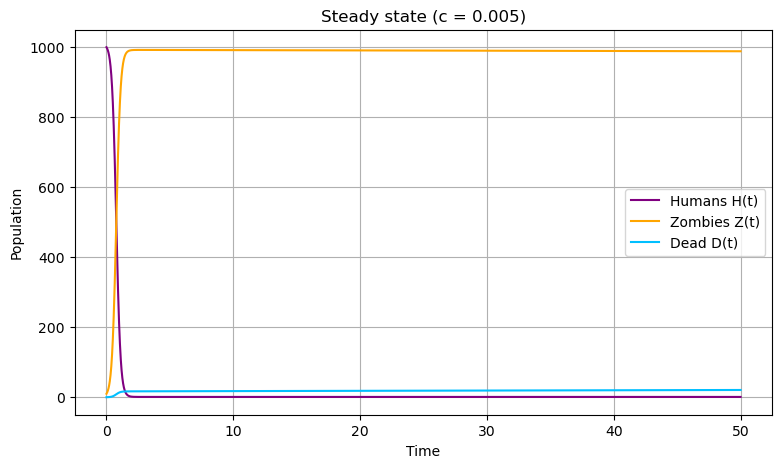

In [147]:
# Model with curing: Z → H at rate c

def F(t, S, beta, gamma, delta, eps, c):
    H, Z, D = S

    dH = -beta*H - gamma*H*Z + c*Z
    dZ =  gamma*H*Z - delta*H*Z + eps*D - c*Z
    dD =  beta*H + delta*H*Z - eps*D

    return np.array([dH, dZ, dD])


def solve_model(params, S0, t0=0, tf=50, h=0.01):
    beta, gamma, delta, eps, c = params
    t_eval = np.linspace(t0, tf, int((tf-t0)/h)+1)
    sol = solve_ivp(lambda t, S: F(t, S, beta, gamma, delta, eps, c),
                    [t0, tf], S0, t_eval=t_eval, method='RK45')
    return sol.t, sol.y[0], sol.y[1], sol.y[2]


# Initial
S0 = np.array([1000., 10., 0.])   # H, Z, D

col_H = "purple"
col_Z = "orange"
col_D = "deepskyblue"


#Steady state behaviour
params_steady = (1e-4, 6e-3, 1e-4, 1e-4, 5e-3)  # last parameter = curing c

t, H, Z, D = solve_model(params_steady, S0)

plt.figure(figsize=(9,5))
plt.plot(t, H, color=col_H, label="Humans H(t)")
plt.plot(t, Z, color=col_Z, label="Zombies Z(t)")
plt.plot(t, D, color=col_D, label="Dead D(t)")
plt.title("Steady state (c = {:.3f})".format(params_steady[-1]))
plt.xlabel("Time")
plt.ylabel("Population")
plt.grid(True)
plt.legend()
plt.show()


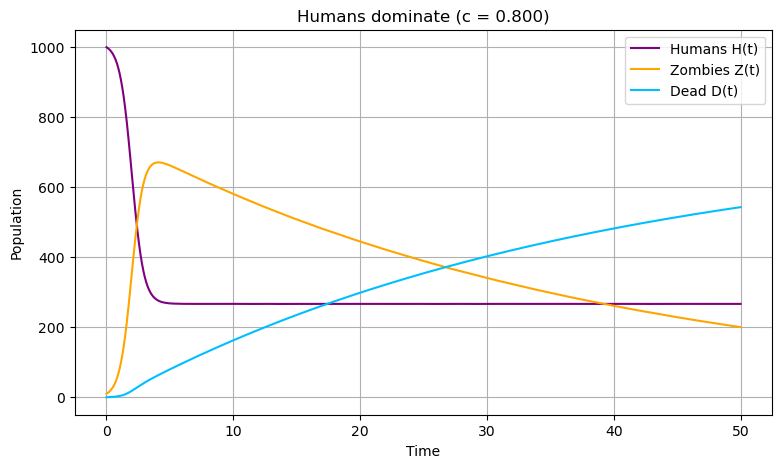

In [149]:
#Humans dominate
params_humans_dominate = (1e-4, 3e-3, 1e-4, 1e-4, 0.8)  # stronger curing

t, H, Z, D = solve_model(params_humans_dominate, S0)

plt.figure(figsize=(9,5))
plt.plot(t, H, color=col_H, label="Humans H(t)")
plt.plot(t, Z, color=col_Z, label="Zombies Z(t)")
plt.plot(t, D, color=col_D, label="Dead D(t)")
plt.title("Humans dominate (c = {:.3f})".format(params_humans_dominate[-1]))
plt.xlabel("Time")
plt.ylabel("Population")
plt.grid(True)
plt.legend()
plt.show()